In [56]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import BaseVAE, GlobalVAE, NormalizingGlobalVAE, SteinGlobalVAE, SteinNormalizingVAE



from morbius import make_mobius_strip
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
def plot3d(d, title):
    d = d.reshape(-1, 3)
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [58]:
import numpy as np

n_samples = 2000

X_mobius, _  = make_mobius_strip(n_samples=2000, radius = 2, width = 3, noise=0.2)

plot3d(X_mobius, "Möbius Strip")

In [59]:
X_S, t = make_s_curve(noise=0.10, random_state=0, n_samples=1000)
plot3d(X_S, "Curve Data")

# Basic VAE

In [60]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )




def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )



In [61]:
X = X_S 

batch_size = X.shape[0]
dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]

out_dim = X.reshape(X.shape[0], -1).shape[1]
lr=5e-3
hidden_dim = 8
z_dim = 2
adam = optim.Adam(lr)

encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}

In [66]:
def plot_vae(vae, rng_key):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    z = vae.encode_batch(X, e_sub)["z"]
    X_recon = vae.decode_latent({"z": z}, d_sub)
    plot3d(X_recon["obs"], "recon")

    plt.figure(figsize=(12, 5))  # Adjust figure size for side-by-side plots

    plt.subplot(1, 2, 1)
    plt.scatter(x=z[:,0], y=z[:,1])
    plt.title("recon latent")

    X_samples = vae.sample(s_sub, 1000)
    z = X_samples["z"]
    plot3d(X_samples["obs"], "samples")

    plt.subplot(1, 2, 2)
    plt.scatter(x=z[:,0], y=z[:,1])
    plt.title("samples latent")

    plt.show()

100%|██████████| 2000/2000 [00:03<00:00, 618.63it/s] 


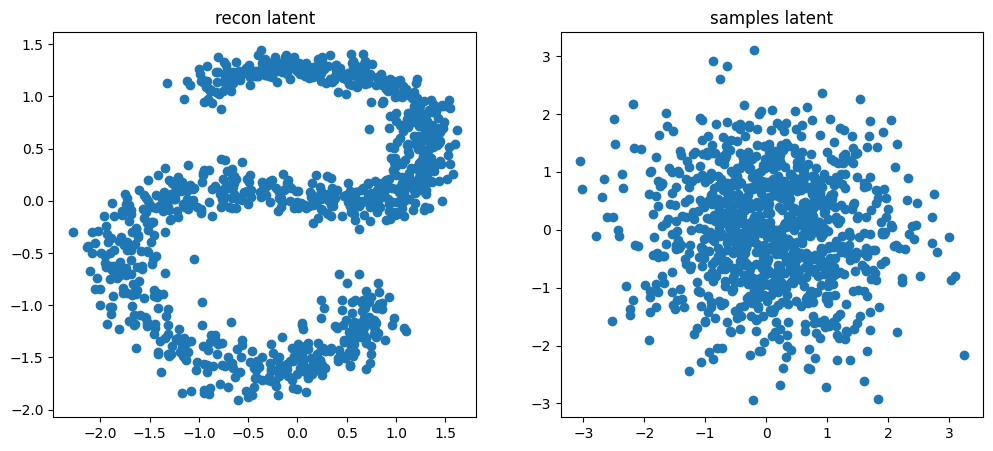

In [68]:
rng_key, sub_key = jax.random.split(rng_key)

base_vae = BaseVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

base_vae.train(dataloader, X.shape[0], adam, 2000, sub_key)

plot_vae(base_vae, sub_key)


# A global Parameter


100%|██████████| 10000/10000 [00:08<00:00, 1180.12it/s]


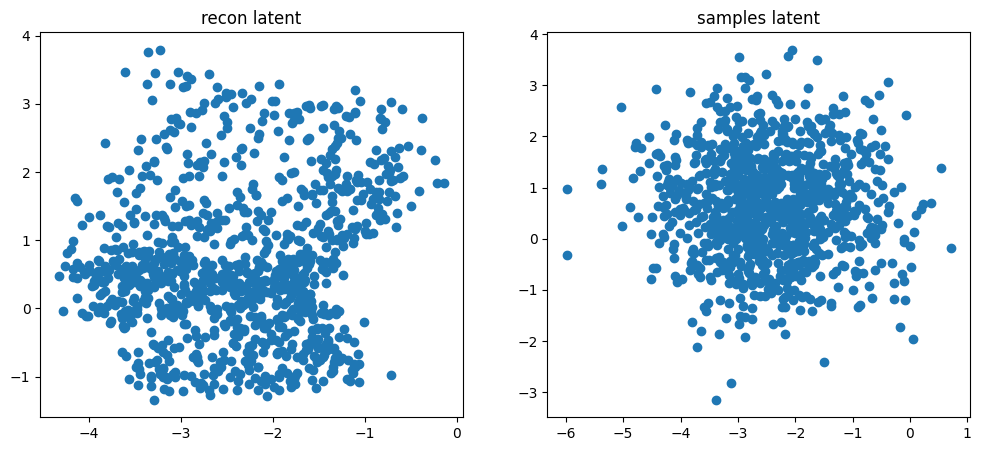

In [69]:
rng_key, sub_key = jax.random.split(rng_key)

global_vae = GlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)

plot_vae(global_vae, sub_key)


# Adding a normalizing flow

100%|██████████| 5000/5000 [00:06<00:00, 793.06it/s] 


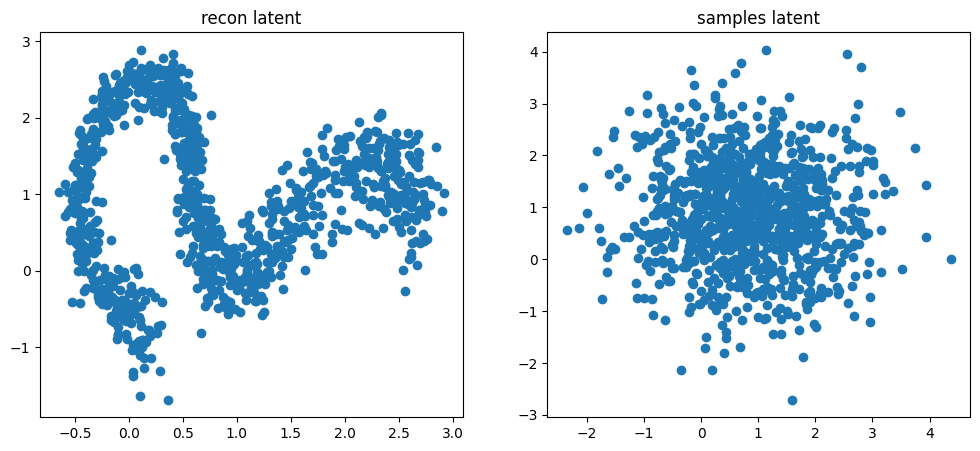

In [70]:
rng_key, sub_key = jax.random.split(rng_key)


flow_args = {"input_dim": z_dim, "hidden_dims": [10, 10], "steps": 5, "inv": False}

flow_vae = NormalizingGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

global_vae.train(dataloader, X.shape[0], adam, 5000, sub_key)

plot_vae(global_vae, sub_key)


# Implementing the stein mixture
